# Response to the reviewr Comment 1.2:

Figures 2F and H both show that the inferential RL model fits better in the first ~15 trials of a block compared to the foraging model, while the latter strategy fits better in the remaining trials. Given that different time points within a block may generate different best models, the underlying neural representation of value might be more complex than suggested by the analyses in Figure 4 (i.e., support for delta rule value updates and value representations). For example, it could be worthwhile accounting for the pattern in Figures 2FH with a hybrid model that switches between inference of the latent state (did a switch occur) over the first few trials in the block and foraging/exploitation of the known states, and interpreting the data in light of that model (if it is the winning model).


A: We fit the model on the first 10/15/all trials per block. we show, for each fit, the LPT of the two models (which reveals is one is better in the beginning or not) and also we show the proba best target selection measured in the first 10/15/all trials. 


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from popy.io_tools import load_behavior
from popy.simulation_helpers import estimate_ll
from popy.simulation_tools import *
from popy.io_tools import load_behavior, load_behavior_yuri
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *
from popy.config import PROJECT_PATH_LOCAL

from popy.simulation_helpers import fit_simulate, simulate_agent
from popy.plotting.plotting_tools import show_target_selection, show_target_selection_compact

from popy.config import PROJECT_PATH_LOCAL, COLORS, MODEL_PARAMS, MODEL_PARAMS_sRL


def load_res(floc_base=None):
    # show bic and LPT values
    dfs = []
    for monkey in ["ka", "po"]:  #:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        if floc_base is None:
            floc = os.path.join(
                PROJECT_PATH_LOCAL,
                "notebooks",
                "behav_modeling",
                "results",
                "fitting",
                f"simulation_results_{monkey}.csv",
            )
        else:
            floc = os.path.join(floc_base, f"simulation_results_{monkey}.csv")
        res_temp = pd.read_csv(floc)

        # add monkey name to the dataframe and move to first col
        res_temp["monkey"] = monkey

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)


def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({"font.size": 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({"font.size": 8})
        w, h = ((12 / 5) / 3) * (len(res_all) / 2), 5 / 1

    # Define the modes and figure
    modes = ["LPT_best"]
    fig, axes = plt.subplots(
        2, 1, figsize=(w / 2.54, h / 2.54), gridspec_kw={"hspace": 0.3}
    )

    # Get unique values
    models = res_all.loc[res_all["monkey"] != "yu_DCZ", "Model"].unique()
    monkeys = res_all.loc[res_all["monkey"] != "yu_DCZ", "monkey"].unique()

    # Iterate over the modes and plot
    for mode_idx, mode in enumerate(modes):
        # Set up positions
        x = np.arange(len(models))
        width = 0.65  # Width of bars

        for i, monkey in enumerate(monkeys):
            ax = axes[i]  # Use separate subplot for each monkey

            data = res_all.loc[
                (res_all["monkey"] == monkey) & (res_all["monkey"] != "yu_DCZ")
            ]
            values = [
                (
                    data.loc[data["Model"] == model, mode].iloc[0]
                    if len(data.loc[data["Model"] == model]) > 0
                    else 0
                )
                for model in models
            ]

            # Create bars with model-based coloring
            for j, (model, value) in enumerate(zip(models, values)):
                hatch = None
                if model.split()[0] == "Standard":
                    # replace  what comes after with RL
                    color = COLORS["Standard RL"]
                    if (
                        not model == "Standard RL - stickiness" and not paper_format
                    ) or (paper_format and not model == "Standard RL"):
                        hatch = "///"  # Dashed filling pattern
                elif model.split()[0] == "Inferential":
                    color = COLORS["Inferential RL"]
                    if (
                        not model == "Inferential RL - stickiness" and not paper_format
                    ) or (paper_format and not model == "Inferential RL"):
                        hatch = "///"  # Dashed filling pattern
                elif model.split()[0] == "Foraging":
                    color = COLORS["Foraging"]
                    if not len(model.split(" ")) == 1:
                        hatch = "///"  # Dashed filling pattern
                else:
                    color = COLORS.get(model, "grey")
                    hatch = None
                alpha = 0.8

                bar = ax.bar(
                    x[j],
                    value,
                    width,
                    color=color,
                    hatch=hatch,
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=alpha,
                )

                # Set hatch color to grey for RL-s models
                if model.split()[-1] == "RL-s":
                    import matplotlib as mpl

                    mpl.rcParams["hatch.color"] = "grey"

            for model, value in zip(models, values):
                print(f"{mode}: {monkey} {model}: {value:.2f}")

            # add monkey name (capitalized) as title, y axis a bit lower
            ax.set_title(monkey.upper(), fontsize=10, y=0.85)

            # Configure axes
            ax.set_ylim(0.3, 0.85)
            ax.set_yticks(np.arange(0.3, 0.9, 0.2))
            ax.set_ylabel("LPT", fontsize=8)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.grid(axis="y", linestyle="dotted", alpha=0.5, zorder=0)

            # Only add x-axis labels to bottom plot
            if i == len(monkeys) - 1:  # Bottom plot
                ax.set_xticks(x)
                if paper_format:
                    ax.set_xticklabels(models, rotation=45, horizontalalignment="right")
                else:
                    ax.set_xticklabels(
                        models, rotation=-90, horizontalalignment="center"
                    )
            else:  # Top plot
                ax.set_xticks(x)
                ax.set_xticklabels([])  # Remove x-axis labels from top plot

    return fig, axes


res_all = load_res()
# res_all = res_all.sort_values(['Model', 'monkey'])

res_all = res_all.sort_values("Model")
res_all

monkey = "ka"
models = {"Inferential RL - stickiness": "Inferential RL", "Foraging": "Foraging"}

flocs = {
    "full": os.path.join(
        PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "fitting"
    ),
    "first15": os.path.join(
        PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "fitting_first15"
    ),
    "first10": os.path.join(
        PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "fitting_first10"
    ),
}


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-x4gooc5f because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


LPT_best: ka Inferential RL: 0.75
LPT_best: ka Foraging: 0.79
LPT_best: po Inferential RL: 0.55
LPT_best: po Foraging: 0.60
LPT_best: ka Inferential RL: 0.68
LPT_best: ka Foraging: 0.72
LPT_best: po Inferential RL: 0.52
LPT_best: po Foraging: 0.56
LPT_best: ka Inferential RL: 0.64
LPT_best: ka Foraging: 0.68
LPT_best: po Inferential RL: 0.49
LPT_best: po Foraging: 0.54


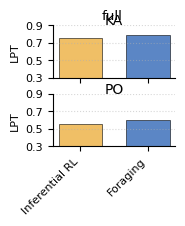

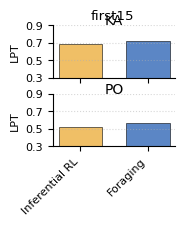

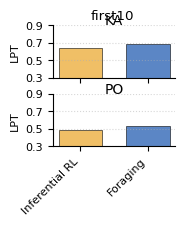

In [ ]:
# show LPT 
for title, floc_base in flocs.items():

    res_all = load_res(floc_base=floc_base)
    res_all = res_all[res_all['Model'].isin(models.keys())].copy()
    # revesre sort
    res_all = res_all.sort_values("Model", ascending=False)
    # rename models from key to values
    res_all["Model"] = res_all["Model"].replace(models)
    
    fig, ax = plot_res(res_all, paper_format=True)
    fig.suptitle(title)

In [ ]:
MODELS = {
    "WSLS": {
        "agent_class": WSLSAgent,
        "fixed_params": {},
        "free_params": ["epsilon"],
    },
    "Standard RL - stickiness": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "stickiness_bias"],
    },
    "Inferential RL - stickiness": {    
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta", "stickiness_bias"],
    },
    "Foraging": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta", "V0"],
    },
}

In [ ]:
# show performance, measure don the first 10/15/all trials per block.
from popy.behavior_data_tools import convert_column_format

# for monkey
lpts_full = []
for monkey in ['ka', 'po']:
    behav_data = load_behavior(monkey)
    behav_data = convert_column_format(behav_data, original="behavior")
    params_all = pd.read_csv(os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "fitting", f"simulation_results_{monkey}.csv"))

    for model_name in MODELS.keys():
        model_params = MODELS[model_name]
        agent_class = model_params["agent_class"]
        fixed_params = model_params["fixed_params"]
        params = params_all.loc[params_all['Model'] == model_name, model_params['free_params']].iloc[0].to_dict()

        ll_full = estimate_ll(agent_class, params, behav_data, fixed_params, return_with_behav=True)
        ll_full['lpt'] = ll_full["logp_action"]
        lpt1 = np.exp(ll_full["logp_action"].mean())
        print(monkey, model_name, lpt1)

        # get lpt vector per blocks, interpolate each block to 40, take and save mean
        lpt_vector = []
        for (session_id, block_id), block_data in ll_full.groupby(["session", "block_id"]):
            lpt_block = block_data["lpt"].values
            # interpolate to 40
            lpt_block_interp = np.interp(
                np.linspace(0, len(lpt_block) - 1, 40),
                np.arange(len(lpt_block)),
                lpt_block,
            )
            lpt_vector.append(lpt_block_interp)

        lpts_full.append({
            "monkey": monkey,
            "model_name": model_name,
            "lpt_vector": np.exp(np.mean(lpt_vector, axis=0)),
            "lpt_vector_std": np.exp(np.std(lpt_vector, axis=0)),
            "n_blocks": len(lpt_vector),
        })
        

ka WSLS 0.40144184152652174
ka Standard RL - stickiness 0.7438614640470586
ka Inferential RL - stickiness 0.7495374574280161
ka Foraging 0.7859683375774421
po WSLS 0.38989025312202075
po Standard RL - stickiness 0.5400251654995354
po Inferential RL - stickiness 0.5527853886473892
po Foraging 0.5943803153313503


In [ ]:
def plot_lpt_vectors(lpts_full, paper_format=True, show_error=True):
    """
    Plot LPT vectors over trials in block for each monkey and model.
    
    Parameters:
    -----------
    lpts_full : list of dict
        Each dict contains 'monkey', 'model_name', 'lpt_vector' (mean), 'lpt_vector_std' (std), and 'n_blocks'
    paper_format : bool
        If True, use paper formatting
    show_error : bool
        If True, show SE error bands
    """
    # Set font size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 2 * 0.95, 2 * 0.8 + 0.15  # width and height in cm
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 6
    
    # Get unique monkeys
    monkeys = sorted(list(set([item['monkey'] for item in lpts_full])))
    
    # Create subplots - one per monkey (vertical arrangement)
    fig, axes = plt.subplots(len(monkeys), 1, figsize=(w, h), sharex=True, sharey=True,
                             gridspec_kw={'hspace': 0.3})
    
    if len(monkeys) == 1:
        axes = [axes]
    
    # Define linewidth
    lw = 1.5 if paper_format else 2
    
    # Map model names to colors
    model_color_map = {
        "Inferential RL - stickiness": COLORS["Inferential RL"],
        "Foraging": COLORS["Foraging"],
        "WSLS": COLORS["WSLS"],
        "Standard RL - stickiness": COLORS["Standard RL"],
    }
    
    # Plot for each monkey
    for monkey_idx, monkey in enumerate(monkeys):
        ax = axes[monkey_idx]
        
        # Get data for this monkey
        monkey_data = [item for item in lpts_full if item['monkey'] == monkey]
        
        for item in monkey_data:
            model_name = item['model_name']
            mean_lpt = np.array(item['lpt_vector'])  # Already mean
            std_lpt = np.array(item['lpt_vector_std'])  # Already std
            n_blocks = item['n_blocks']
            
            # Calculate standard error
            se_lpt = std_lpt / np.sqrt(n_blocks)
            
            # Get color
            color = model_color_map.get(model_name, 'grey')
            
            # Get label (simplified model name)
            if model_name == "Inferential RL - stickiness":
                label = "Inferential RL"
            elif model_name == 'Standard RL - stickiness':
                label = 'Standard RL'
            else:
                label = model_name
            
            # Plot mean
            ax.plot(mean_lpt, color=color, label=label, linewidth=lw, alpha=0.8)
            
            # Plot error band (using SE)
            if show_error:
                ax.fill_between(np.arange(len(mean_lpt)), 
                               mean_lpt - se_lpt, 
                               mean_lpt + se_lpt, 
                               color=color, alpha=0.1)
        
        # Formatting
        LEN_BLOCK = 40
        ax.axvline(LEN_BLOCK - 5, color='k', linestyle='--', alpha=0.5, zorder=-1)
        ax.set_ylabel('Likelihood per trial-in-block')
        '''ax.set_ylim([0.5, 1])
        ax.set_yticks(np.arange(0.5, 1, 0.2))'''
        ax.set_xlabel('Trials in block')
        
        # Title
        ax.set_title(monkey.upper(), fontsize=10, y=0.85)
        
        # Spines
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
        # Grid
        ax.grid(axis='y', linestyle='dotted', alpha=0.5, zorder=0)
        
        # Legend
        ax.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=True, fontsize=8)    
    
    if not paper_format or monkey_idx == len(monkeys) - 1:
            return fig, axes

(<Figure size 400x600 with 2 Axes>,
 array([<Axes: title={'center': 'KA'}, xlabel='Trials in block', ylabel='Likelihood per trial-in-block'>,
        <Axes: title={'center': 'PO'}, xlabel='Trials in block', ylabel='Likelihood per trial-in-block'>],
       dtype=object))

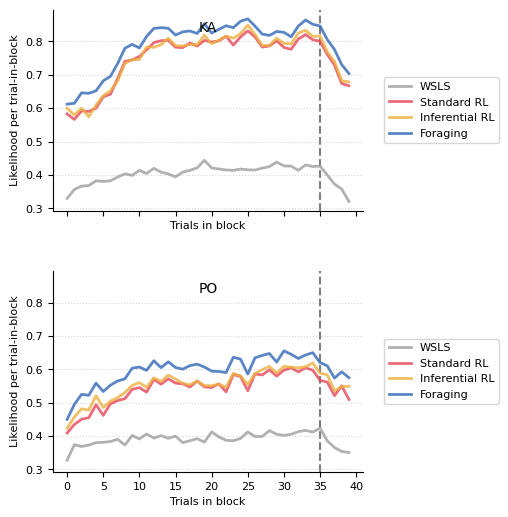

In [ ]:
plot_lpt_vectors(lpts_full, paper_format=False, show_error=False)